In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os
import re
pd.set_option("display.max_rows", None)

# ------------------------------------------------------------
# helper ------------------------------------------------------
def calculate_and_contour_bright_areas_adjusted(image,
                                                threshold_value,
                                                contour_thickness,
                                                num_contours):
    _, thresh = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    areas_and_centroids = []
    for c in contours:
        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        if perimeter == 0:
            continue
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = w / float(h)
        if 0.3 < aspect_ratio < 2.1:  # filter out weird shapes
            M = cv2.moments(c)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                areas_and_centroids.append((area, (cx, cy), c))

    largest = sorted(areas_and_centroids,
                     key=lambda x: x[0],
                     reverse=True)[:num_contours]
    largest = sorted(largest, key=lambda x: x[1][1])  # sort by y

    img_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(img_rgb, [c[2] for c in largest],
                     -1, (0, 255, 0), contour_thickness)
    return img_rgb, largest

# ------------------------------------------------------------
# main single-image routine ----------------------------------
def process_image(image_path,
                  brightness=130,
                  thickness=5,
                  pixel_per_mm=610,
                  to_plot=False):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image is None:
        return "Image not loaded"

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # green & orange HSV bounds
    lower_green = np.array([36, 25, 25])
    upper_green = np.array([86, 255, 255])
    lower_orange = np.array([5, 10, 100])
    upper_orange = np.array([35, 255, 255])

    # Percentage of green pixels – quick heuristic
    green_mask_full = cv2.inRange(hsv_image, lower_green, upper_green)
    green_fraction = np.count_nonzero(green_mask_full) / green_mask_full.size

    if green_fraction >= 0.005:          # ≥0.5 % pixels are green → treat as colour
        # use orange mask to isolate liver region, then grab its green channel
        orange_mask = cv2.inRange(hsv_image, lower_orange, upper_orange)
        green_channel = cv2.bitwise_and(image, image,
                                        mask=orange_mask)[:, :, 1]
    else:                                # image already essentially greyscale
        # just work with a single-channel grayscale copy
        green_channel = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Contrast-limit adaptive histogram equalisation
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    green_channel_clahe = clahe.apply(green_channel)

    # how many contours to keep = how many numbers in file name
    file_name = os.path.basename(image_path)
    N = sum(token.isdigit() for token in file_name.split())

    img_with_c, areas_centroids = calculate_and_contour_bright_areas_adjusted(
        green_channel_clahe, brightness, thickness, N)

    # convert areas to µm² (assuming 1 mm = pixel_per_mm px)
    result = [area / pixel_per_mm**2 * 1e6 for area, _, _ in areas_centroids]

    if to_plot:
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(img_with_c, cv2.COLOR_BGR2RGB))
        plt.title(file_name)
        plt.axis('off')
        plt.show()

    return result

# ------------------------------------------------------------
# multi-image driver -----------------------------------------
def process_images_in_folder(folder_path,
                             brightness=130,
                             thickness=5,
                             pixel_per_mm=610,
                             to_plot=False):
    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg',
                                          '.tif', '.tiff'))]

    results = []
    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)

        pattern = r"fish ((?:\d+ ?)+).*top (\w+) wt and bottom (\w+) ko"
        match = re.search(pattern, image_file)
        if match:
            fish_numbers = list(map(int, match.group(1).split()))
            num_map = {'zero': 0, 'one': 1, 'two': 2,
                       'three': 3, 'four': 4}
            top_num = num_map.get(match.group(2), 0)
            bottom_num = num_map.get(match.group(3), 0)
            types = ['wt'] * top_num + ['ko'] * bottom_num
            color = 'bw' if 'bw' in image_file else 'orange'
        else:
            fish_numbers = []
            types = []
            color = ''

        try:
            processed = process_image(image_path,
                                      brightness,
                                      thickness,
                                      pixel_per_mm,
                                      to_plot)
            for idx, area in enumerate(processed):
                results.append({"fish number": fish_numbers[idx],
                                "type": types[idx],
                                "area in µm²": round(area),
                                "color": color})
        except Exception as e:
            print(f"Error processing {image_file}: {e}")

    return pd.DataFrame(results)


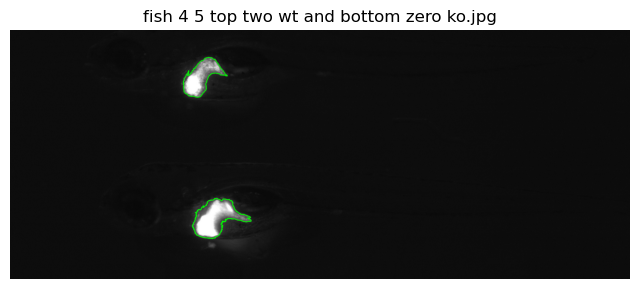

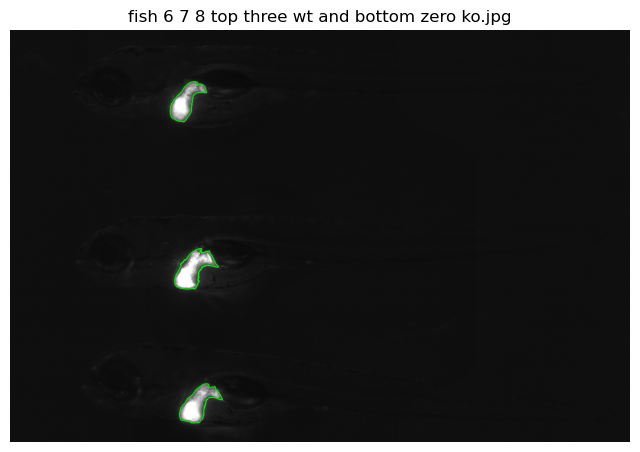

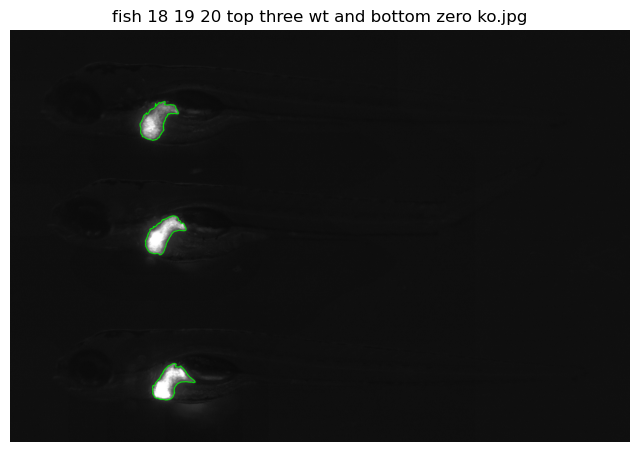

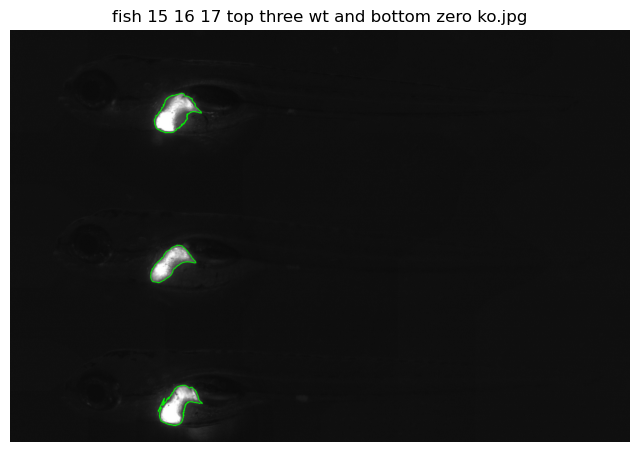

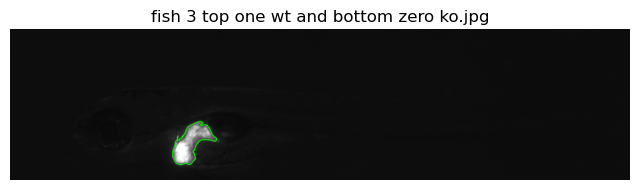

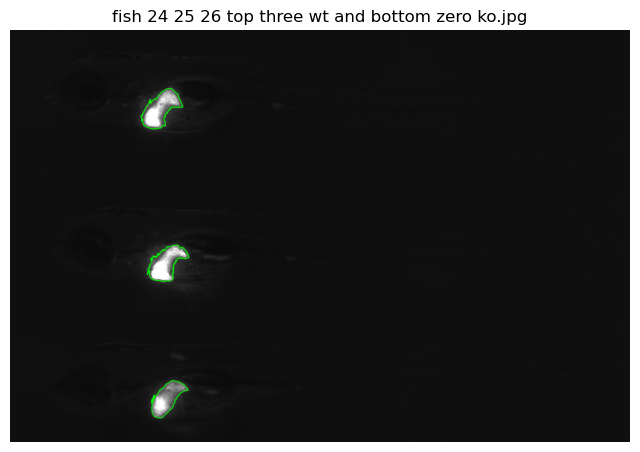

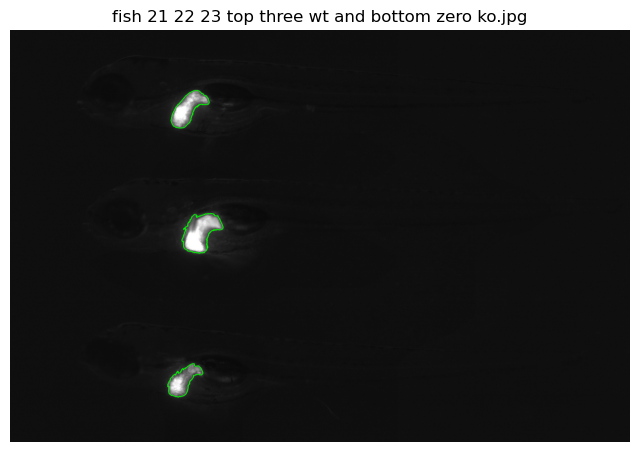

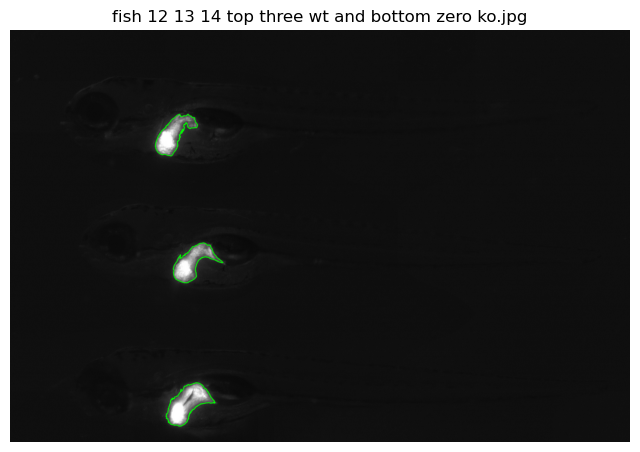

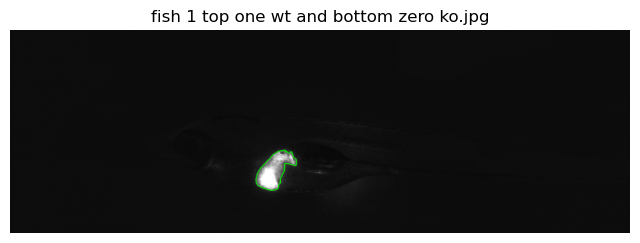

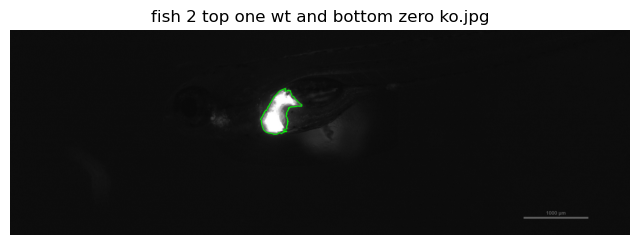

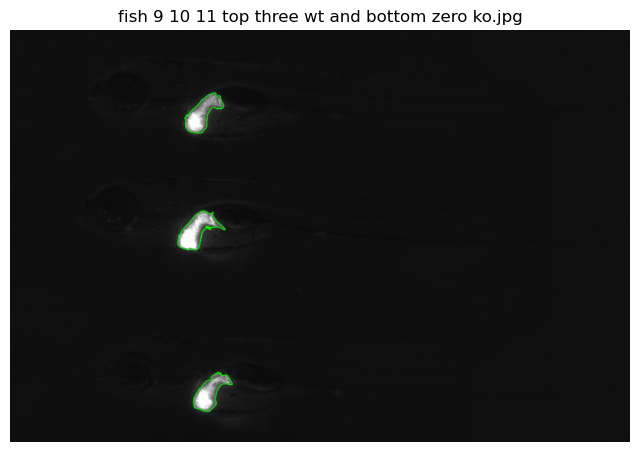

In [8]:
# folder 1 610 pixels per mm
folder_path = "/Users/tengiz/Desktop/Fish/wt oc lipans clutch 1"
data = process_images_in_folder(folder_path, brightness=60, pixel_per_mm=882,to_plot=True)

In [9]:
data

,fish number,type,area in µm²,color
0,4,wt,67640,orange
1,5,wt,98430,orange
2,6,wt,57406,orange
3,7,wt,72987,orange
4,8,wt,66582,orange
5,18,wt,62829,orange
6,19,wt,64677,orange
7,20,wt,62555,orange
8,15,wt,84227,orange
9,16,wt,63307,orange


In [ ]:
from scipy.stats import ttest_ind

# Creating DataFrame
df = data

# Separating the data into groups based on the type
group_ko = df[df['type'] == 'ko']['area in µm²']
group_wt = df[df['type'] == 'wt']['area in µm²']

# Performing the t-test
t_stat, p_value = ttest_ind(group_ko, group_wt, equal_var=True)

# Printing the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: nan
P-value: nan


/opt/homebrew/Caskroom/miniconda/base/envs/fish/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [12]:
data.groupby('type')['area in µm²'].mean().reset_index()

,type,area in µm²
0,wt,68895.0
